In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.fft import fft, fftfreq, fftshift
from scipy.optimize import least_squares

base = Path('.')
X_all_0 = np.load(base / '0528_X_all_0.npy')
#X_all_0 = np.load(base / 'X_all_0_small.npy')
X_all_1 = np.load(base / '0528_X_all_1.npy')
#X_all_1 = np.load(base / 'X_all_1_small.npy')
y_all_0 = np.load(base / '0528_y_all_0.npy')
y_all_0 = y_all_0[0:50000]
y_all_1 = np.load(base / '0528_y_all_1.npy')
y_all_1 = y_all_1[0:50000]

In [2]:
#calculate the shots per class

num_0_shots = len(y_all_0)
num_1_shots = len(y_all_1)

print(f'Number of shots for class 0: {num_0_shots}'
      f'\nNumber of shots for class 1: {num_1_shots}')

#calculate samples per shot
samples_per_shot_0 = X_all_0.shape[1]
samples_per_shot_1 = X_all_1.shape[1]

print(f'Number of samples per shot for class 0: {samples_per_shot_0}'
      f'\nNumber of samples per shot for class 1: {samples_per_shot_1}')

Number of shots for class 0: 50000
Number of shots for class 1: 50000
Number of samples per shot for class 0: 1540
Number of samples per shot for class 1: 1540


In [3]:
#IQ samples are interleaved, X looks like [I0, Q0, I1, Q1, I2, Q2, ...]
I_min = min(np.min(X_all_0[:, 0::2]), np.min(X_all_1[:, 0::2]))
I_max = max(np.max(X_all_0[:, 0::2]), np.max(X_all_1[:, 0::2]))
Q_min = min(np.min(X_all_0[:, 1::2]), np.min(X_all_1[:, 1::2]))
Q_max = max(np.max(X_all_0[:, 1::2]), np.max(X_all_1[:, 1::2]))

print(f'Minimum I value: {I_min}, Maximum I value: {I_max}')
print(f'Minimum Q value: {Q_min}, Maximum Q value: {Q_max}')

Minimum I value: -4883.0, Maximum I value: 4822.0
Minimum Q value: -4810.0, Maximum Q value: 4716.0


In [4]:
mean_I_0 = np.mean(X_all_0[:, 0::2])#, axis=0)
mean_Q_0 = np.mean(X_all_0[:, 1::2])#, axis=0)
mean_I_1 = np.mean(X_all_1[:, 0::2])#, axis=0)
mean_Q_1 = np.mean(X_all_1[:, 1::2])#, axis=0)

print(f'Mean I value for state 0: {mean_I_0}, Mean Q value for state 0: {mean_Q_0}')
print(f'Mean I value for state 1: {mean_I_1}, Mean Q value for state 1: {mean_Q_1}')

Mean I value for state 0: 13.279152337662337, Mean Q value for state 0: 137.56756376363637
Mean I value for state 1: 141.674451, Mean Q value for state 1: -62.930896623376626


Covariance matrix for state 0:
[[ 1.10847400e+09 -3.98397462e+08]
 [-3.98397462e+08  1.31627728e+09]]
Covariance matrix for state 1:
[[ 1.50519727e+09 -9.75491229e+08]
 [-9.75491229e+08  2.23312895e+09]]


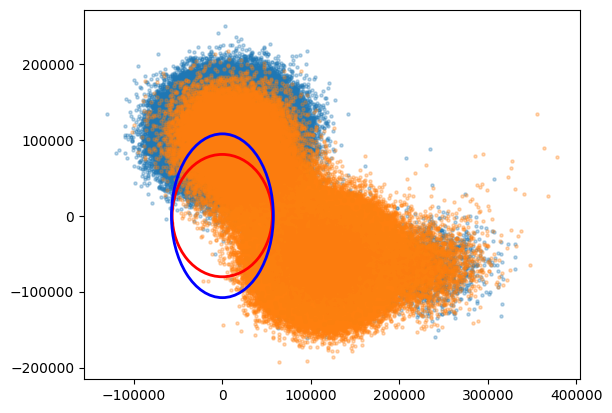

In [5]:
#now calculate the covariance between IQ data
I_0 = np.sum(X_all_0[:,0::2], axis=1)
Q_0 = np.sum(X_all_0[:,1::2], axis=1)
I_1 = np.sum(X_all_1[:,0::2], axis=1)
Q_1 = np.sum(X_all_1[:,1::2], axis=1)

cov_IQ_0 = np.cov(I_0,Q_0)
cov_IQ_1 = np.cov(I_1,Q_1)

print(f'Covariance matrix for state 0:\n{cov_IQ_0}')
print(f'Covariance matrix for state 1:\n{cov_IQ_1}')

#using this matrix calculate eigenvalues and eigenvectors
eigenvalues_0, eigenvectors_0 = np.linalg.eig(cov_IQ_0)
eigenvalues_1, eigenvectors_1 = np.linalg.eig(cov_IQ_1)

plt.scatter(
    I_0,
    Q_0,
    alpha=0.3,
    s=5,
    label="State 0"
)

plt.scatter(
    I_1,
    Q_1,
    alpha=0.3,
    s=5,
    label="State 1"
)

width = 2*np.sqrt(eigenvalues_0[0])*2
height = 2*np.sqrt(eigenvalues_0[1])*2
#plot the ellipse for state 0
ellipse_0 = Ellipse(xy=(mean_I_0, mean_Q_0), width=width, height=height, edgecolor='r', fc='None', lw=2, label='State 0 Covariance Ellipse')
plt.gca().add_patch(ellipse_0)

ellipse_1 = Ellipse(xy=(mean_I_1, mean_Q_1), width=2*np.sqrt(eigenvalues_1[0])*2, height=2*np.sqrt(eigenvalues_1[1])*2, edgecolor='b', fc='None', lw=2, label='State 1 Covariance Ellipse')
plt.gca().add_patch(ellipse_1)


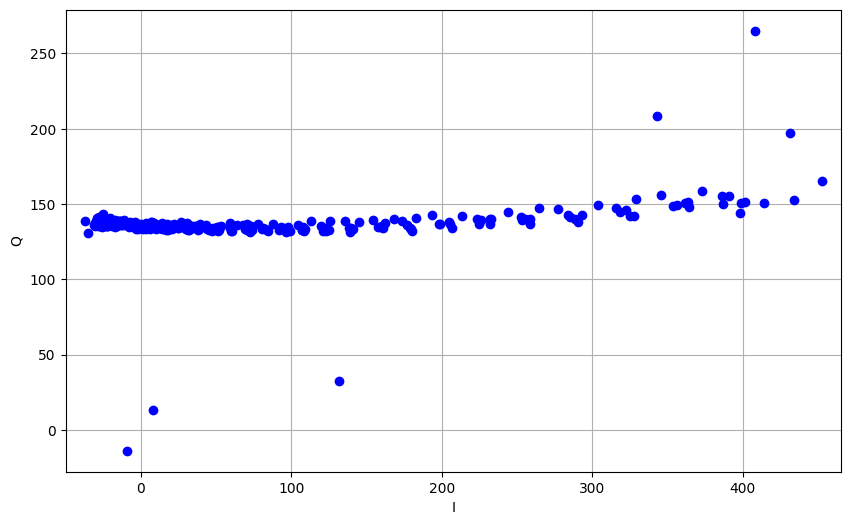

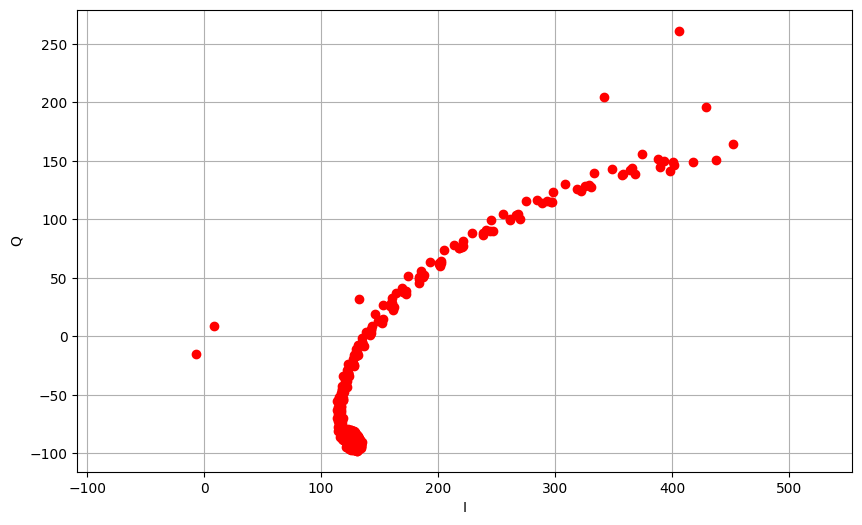

In [6]:
#time domain trajectory
mean_I_0_axis = np.mean(X_all_0[:, 0::2], axis=0)
mean_Q_0_axis = np.mean(X_all_0[:, 1::2], axis=0)
mean_I_1_axis = np.mean(X_all_1[:, 0::2], axis=0)
mean_Q_1_axis = np.mean(X_all_1[:, 1::2], axis=0)


plt.figure(figsize=(10, 6))
plt.plot(mean_I_0_axis, mean_Q_0_axis, 'bo', label='Mean State 0')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

plt.figure(figsize=(10, 6))
plt.plot(mean_I_1_axis, mean_Q_1_axis, 'ro', label='Mean State 1')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

In [7]:
#print the 1 state time domain trajectory
print("Mean State 0 Time Domain Trajectory:")
for i in range(len(mean_I_0_axis)):
    print(f"Sample {i}: I = {mean_I_0_axis[i]}, Q = {mean_Q_0_axis[i]}")
print("Mean State 1 Time Domain Trajectory:")
for i in range(len(mean_I_1_axis)):
    print(f"Sample {i}: I = {mean_I_1_axis[i]}, Q = {mean_Q_1_axis[i]}")

Mean State 0 Time Domain Trajectory:
Sample 0: I = 7.903012, Q = 13.247818
Sample 1: I = -8.913274, Q = -13.903758
Sample 2: I = 132.02983, Q = 32.570742
Sample 3: I = 342.96559, Q = 208.681702
Sample 4: I = 408.276462, Q = 265.127274
Sample 5: I = 431.299654, Q = 196.946842
Sample 6: I = 452.535136, Q = 165.11774
Sample 7: I = 433.998336, Q = 152.635226
Sample 8: I = 414.363866, Q = 150.712062
Sample 9: I = 398.939954, Q = 150.971842
Sample 10: I = 397.966966, Q = 144.273866
Sample 11: I = 401.28621, Q = 151.255636
Sample 12: I = 390.86504, Q = 155.356478
Sample 13: I = 386.612932, Q = 150.228268
Sample 14: I = 385.9702, Q = 155.17732
Sample 15: I = 372.661876, Q = 158.628046
Sample 16: I = 363.318078, Q = 151.01223
Sample 17: I = 364.033572, Q = 147.79209
Sample 18: I = 361.775708, Q = 150.571872
Sample 19: I = 356.258112, Q = 149.49465
Sample 20: I = 353.970116, Q = 148.793298
Sample 21: I = 345.702908, Q = 155.702096
Sample 22: I = 329.413056, Q = 153.451652
Sample 23: I = 324.8127

Noise I for state 0: [[ -609.903012  -671.086726  -135.02983  ...   -51.834294   569.661618
   -399.707136]
 [ -787.903012 -1203.086726 -1632.02983  ...  -460.834294   970.661618
    516.292864]
 [ -782.903012 -1022.086726   328.97017  ... -1254.834294 -1153.338382
     35.292864]
 ...
 [ -734.903012 -1671.086726 -1944.02983  ...   440.165706  -384.338382
    612.292864]
 [ -123.903012   279.913274   110.97017  ... -1138.834294  -283.338382
   -603.707136]
 [  342.096988   984.913274  -125.02983  ... -1082.834294  -511.338382
   -698.707136]]
Noise Q for state 0: [[   54.752182  -546.096242  -383.570742 ... -1287.76409    542.17198
    680.962028]
 [  113.752182   -28.096242   -44.570742 ...   539.23591    261.17198
    165.962028]
 [  151.752182 -1434.096242  -521.570742 ...  -350.76409  -1379.82802
  -1089.037972]
 ...
 [  395.752182   341.903758 -1342.570742 ...  -969.76409     -8.82802
    222.962028]
 [  298.752182   767.903758   214.429258 ...   148.23591   1861.17198
    972.962

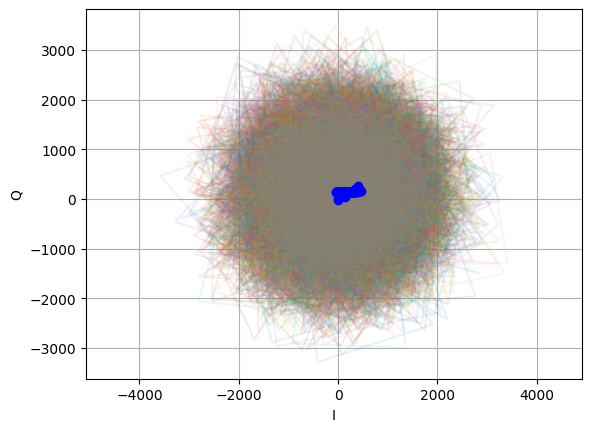

In [8]:
state_I_0 = X_all_0[:, 0::2]
state_Q_0 = X_all_0[:, 1::2]

noise_I_0 = state_I_0 - mean_I_0_axis
noise_Q_0 = state_Q_0 - mean_Q_0_axis

print(f'Noise I for state 0: {noise_I_0}')
print(f'Noise Q for state 0: {noise_Q_0}')

#standard deviation
std_I_0 = np.std(noise_I_0, axis=0)
std_Q_0 = np.std(noise_Q_0, axis=0)

for shot in range(100):
    plt.plot(
        state_I_0[shot],
        state_Q_0[shot],
        alpha=0.1
    )

plt.plot(mean_I_0_axis, mean_Q_0_axis, 'bo', label='Mean State 0')
plt.xlabel("I")
plt.ylabel("Q")
plt.axis("equal")
plt.grid()

In [9]:
mean_I_0_trace = np.mean(X_all_0[:, 0::2], axis=1)
mean_Q_0_trace = np.mean(X_all_0[:, 1::2], axis=1)
mean_I_1_trace = np.mean(X_all_1[:, 0::2], axis=1)
mean_Q_1_trace = np.mean(X_all_1[:, 1::2], axis=1)

noise_I_0_trace = I_0 - mean_I_0_trace
noise_Q_0_trace = Q_0 - mean_Q_0_trace
noise_I_1_trace = I_1 - mean_I_1_trace
noise_Q_1_trace = Q_1 - mean_Q_1_trace                          

sigma_I_0 = np.std(noise_I_0_trace,axis=0)
sigma_Q_0 = np.std(noise_Q_0_trace,axis=0)
sigma_I_1 = np.std(noise_I_1_trace,axis=0)
sigma_Q_1 = np.std(noise_Q_1_trace,axis=0)

print(f'Standard deviation of I for state 0: {sigma_I_0}, Standard deviation of Q for state 0: {sigma_Q_0}')
print(f'Standard deviation of I for state 1: {sigma_I_1}, Standard deviation of Q for state 1: {sigma_Q_1}')

Standard deviation of I for state 0: 33250.481270464734, Standard deviation of Q for state 0: 36233.38202223858
Standard deviation of I for state 1: 38746.44766839395, Standard deviation of Q for state 1: 47194.57519338486


In [10]:
# Load the saved FFT arrays for future use
X_all_0_fft_loaded = np.load('X_all_0_fft.npy')
X_all_1_fft_loaded = np.load('X_all_1_fft.npy')

print('Loaded FFT arrays from disk:')
print(X_all_0_fft_loaded.shape)
print(X_all_1_fft_loaded.shape)

Loaded FFT arrays from disk:
(500000, 1540)
(500000, 1540)


In [11]:
var_I_0 = np.var(I_0)
var_Q_0 = np.var(Q_0)
var_I_1 = np.var(I_1)
var_Q_1 = np.var(Q_1)

cov_IQ_0_scalar = cov_IQ_0[0, 1]
cov_IQ_1_scalar = cov_IQ_1[0, 1]

cov_t_0 = np.array([
    [var_I_0, cov_IQ_0_scalar],
    [cov_IQ_0_scalar, var_Q_0]
])

cov_t_1 = np.array([
    [var_I_1, cov_IQ_1_scalar],
    [cov_IQ_1_scalar, var_Q_1]
])

In [12]:
I_trace = np.mean(X_all_0[:, 0::2], axis=1)
Q_trace = np.mean(X_all_0[:, 1::2], axis=1)

I_s = np.sum(I_trace)
Q_s = np.sum(Q_trace)

# phi values are fitted from the average trajectory later, not randomly initialized here
phi_0 = 0.0
phi_1 = 0.0
phi_sigma_0 = 0.0
phi_sigma_1 = 0.0

In [13]:
def calculate_mean_phase(X):

    sum_phase = np.zeros(770)

    for i in range(len(X)):

        I = X[i,0::2]
        Q = X[i,1::2]

        phase = np.unwrap(np.arctan2(Q,I))

        sum_phase += phase

    return sum_phase / len(X)

mean_phase_0 = calculate_mean_phase(X_all_0)
mean_phase_1 = calculate_mean_phase(X_all_1)
#----------------------------------------------
# def extract_phase(z_real, z_ss=None):

#     if z_ss is None:
#         z_ss = np.mean(z_real[-100:])

#     return np.unwrap(np.angle(z_real - z_ss))


# # keep the phase trajectories available for debugging and comparison
# mean_phase_0 = extract_phase(np.mean(X_all_0, axis=0)[0::2] + 1j * np.mean(X_all_0, axis=0)[1::2])
# mean_phase_1 = extract_phase(np.mean(X_all_1, axis=0)[0::2] + 1j * np.mean(X_all_1, axis=0)[1::2])

In [14]:
#fit delta_0 and delta_1 from their respective trajectories
delta_0 = mean_phase_0[-1] - mean_phase_0[0]
delta_1 = mean_phase_1[-1] - mean_phase_1[0]

mean_real0 = np.mean(X_all_0, axis=0)
mean_real1 = np.mean(X_all_1, axis=0)

z0_real = mean_real0[0::2] + 1j*mean_real0[1::2]
z1_real = mean_real1[0::2] + 1j*mean_real1[1::2]

print(z0_real.shape)
print(z1_real.shape)
#--------------------------------------------------------------------
#fit delta_0 and delta_1 from their respective trajectories
# mean_real0 = np.mean(X_all_0, axis=0)
# mean_real1 = np.mean(X_all_1, axis=0)

# z0_real = mean_real0[0::2] + 1j*mean_real0[1::2]
# z1_real = mean_real1[0::2] + 1j*mean_real1[1::2]

# t = np.arange(len(z0_real)) * 2e-9

# mean_phase_0 = extract_phase(z0_real)
# mean_phase_1 = extract_phase(z1_real)

# p0 = np.polyfit(t, mean_phase_0, 1)
# p1 = np.polyfit(t, mean_phase_1, 1)

# delta_0 = p0[0]
# delta_1 = p1[0]

# phi_0 = p0[1]
# phi_1 = p1[1]

# phi_sigma_0 = np.std(mean_phase_0 - np.polyval(p0, t))
# phi_sigma_1 = np.std(mean_phase_1 - np.polyval(p1, t))

# print(z0_real.shape)
# print(z1_real.shape)
# print(f'delta_0={delta_0}, delta_1={delta_1}, phi_0={phi_0}, phi_1={phi_1}')

(770,)
(770,)


In [15]:
offset_I = np.mean(
    np.concatenate([
        z0_real.real[-100:],
        z1_real.real[-100:]
    ])
)

offset_Q = np.mean(
    np.concatenate([
        z0_real.imag[-100:],
        z1_real.imag[-100:]
    ])
)

In [16]:
# reconstruct all shots as complex arrays

shots0 = X_all_0[:,0::2] + 1j*X_all_0[:,1::2]
shots1 = X_all_1[:,0::2] + 1j*X_all_1[:,1::2]

noise0 = shots0 - z0_real
noise1 = shots1 - z1_real

cov_t = []

for t in range(770):

    iq = np.column_stack([
        noise0[:,t].real,
        noise0[:,t].imag
    ])

    cov_t.append(np.cov(iq,rowvar=False))

In [17]:
print(np.std(noise0.real))
print(np.std(noise0.imag))

837.0732036172076
837.248252196993


In [ ]:
def cavity_response(params,state,n=770,dt=2e-9):

    (
    kappa,
    delta0,
    delta1,

    ass0_real,
    ass0_imag,

    ass1_real,
    ass1_imag,

    a0_real,
    a0_imag,

    phase,
    gain
    ) = params


    delta = delta0 if state==0 else delta1

    #random startup phase
    shot_phase = np.random.normal(0, np.std(phase))

    t=np.arange(n)*dt

    if state==0:
        a_ss = ass0_real + 1j*ass0_imag
    else:
        a_ss = ass1_real + 1j*ass1_imag

    a0 = a0_real + 1j*a0_imag

    a=a_ss+(a0-a_ss)*np.exp(
        (-kappa/2+1j*delta)*t
    )

    z=gain*a*np.exp(1j*phase + shot_phase) #remove +shot_phase later if need be
    z += offset_I+1j*offset_Q

    omega, phi0 = np.polyfit(np.arange(len(phase)), phase, 1)

    phi = phi0 + omega * t

    return z, phi

In [19]:
def readout_chain(a, state):

    # gain (from your ADC scale)
    gain = 4000 * np.random.normal(1, 0.05)
    #gain = 3000

    # global phase rotation (LO / mixer / FPGA)
    phi_mu, phi_sigma = (phi_0, phi_sigma_0) if state == 0 else (phi_1, phi_sigma_1)
    phi = np.random.normal(phi_mu, phi_sigma)

    z = gain * a * np.exp(1j * phi)

    return z

In [20]:
#---------------- old residual model -------------------
def residual(params, state, target):
    n = len(target)
    z = cavity_response(params, state, n=n)
    #weights = np.exp(-np.arange(n) / 275)
    #weights = 2*np.exp(np.arange(n) / 300)
    weights = np.exp(-np.arange(n)/200) #good weights------

    #weights = np.ones(n) #probably delete later
    #weights = np.exp(-np.arange(n)/1000) #slow decay
    #--------------------
    #or try:
    #weights = np.ones(n)
    #weights[:100] *= 5

    residual = weights * (z - target)
    return np.concatenate([residual.real, residual.imag])

#-------------------- new residual model --------------------
#dogshit
# def residual(params,state,z_real):

#     z_fit = cavity_response(params,state)

#     err_time = np.abs(z_fit-z_real)

#     # trajectory derivative
#     dz_real = np.diff(z_real)
#     dz_fit = np.diff(z_fit)

#     err_velocity = np.abs(dz_fit-dz_real)

#     return np.concatenate([
#         err_time,
#         0.5*err_velocity
#     ])

In [21]:
initial = [
    1/(100e-9),     # kappa
    -2*np.pi*2e6,   # delta0
     2*np.pi*2e6,   # delta1
    1,              # a_ss_real0
    0,              # a_ss_imag0
    1,              # a_ss_real1
    0,              # a_ss_imag1
    1,              # a0_real
    0,              # a0_imag
    0,              # phase
    3000            # gain
]

lower = [
    1e3,        # kappa
    -np.inf,    # delta0
    -np.inf,    # delta1
    -np.inf,    # a_ss_real0
    -np.inf,    # a_ss_imag0
    -np.inf,    # a_ss_real1
    -np.inf,    # a_ss_imag1
    -np.inf,    # a0_real
    -np.inf,    # a0_imag
    -np.pi,     # phase
    0           # gain
]

upper = [
    np.inf,
    np.inf,
    np.inf,
    np.inf,
    np.inf,
    np.inf,
    np.inf,
    np.inf,
    np.inf,
    np.pi,
    np.inf
]

bounds=(lower,upper)

# fit0 = least_squares(
#     lambda p: residual(p,0,z0_real),
#     initial,
#     bounds=bounds
# )

# fit1 = least_squares(
#     lambda p: residual(p,1,z1_real),
#     initial,
#     bounds=bounds
# )

# params0 = fit0.x
# params1 = fit1.x

# print(fit0.x)
# print(fit1.x)
# print(params0)
# print(params1)


#----------------- fit both states simultaneously ----------------
def residual_joint(params, z0_target, z1_target):
    n = len(z0_target)
    weights = np.exp(-np.arange(n) / 200)

    z0_fit = cavity_response(params, 0, n=n)
    z1_fit = cavity_response(params, 1, n=n)

    r0 = weights * (z0_fit - z0_target)
    r1 = weights * (z1_fit - z1_target)

    return np.concatenate([r0.real, r0.imag, r1.real, r1.imag])


fit_joint = least_squares(
    lambda p: residual_joint(p, z0_real, z1_real),
    initial,
    bounds=bounds
)

params0 = fit_joint.x
params1 = fit_joint.x

print(params0)
print(params1)

[ 1.01720706e+07 -4.54101244e+04  3.64588334e+06 -3.07607069e-02
  2.98501165e-02  2.70625462e-02 -4.07594194e-02  9.14256911e-02
  3.18694928e-02  6.96860703e-06  3.61911904e+03]
[ 1.01720706e+07 -4.54101244e+04  3.64588334e+06 -3.07607069e-02
  2.98501165e-02  2.70625462e-02 -4.07594194e-02  9.14256911e-02
  3.18694928e-02  6.96860703e-06  3.61911904e+03]


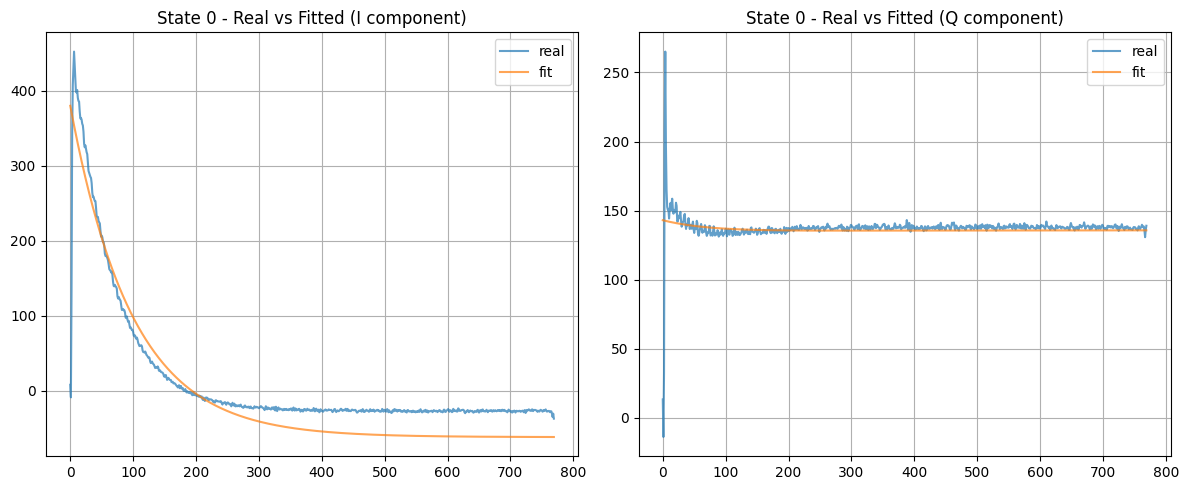

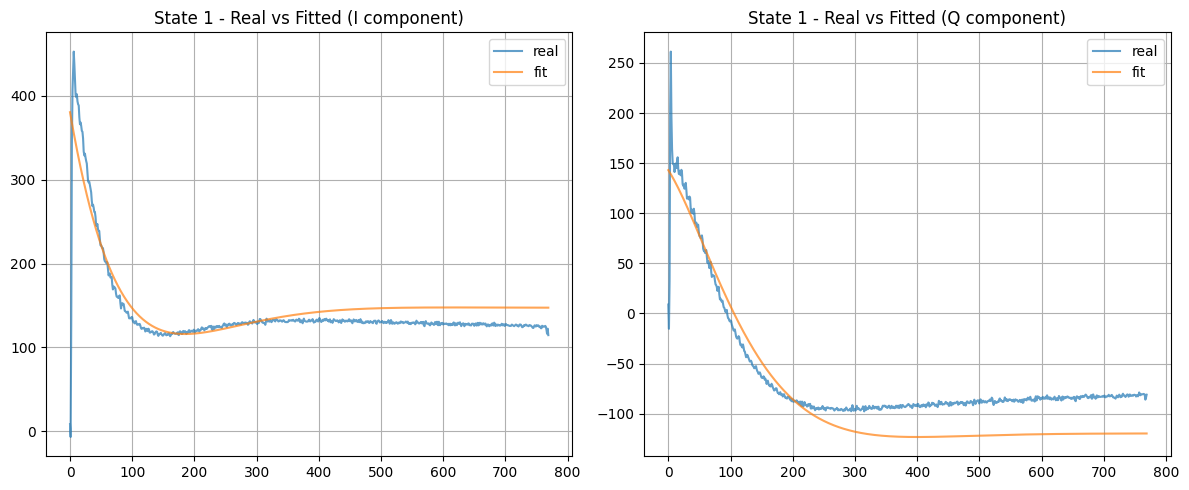

State 0 fit max magnitude: 406.22062336211377
State 0 fit I std: 96.92194995705034
State 0 fit Q std: 1.3829256808666086
State 1 fit max magnitude: 406.22062336211377
State 1 fit I std: 42.35455817257924
State 1 fit Q std: 69.42540406937754


In [22]:
# Validate fitted cavity response parameters
z0_fit = cavity_response(params0, 0)
z1_fit = cavity_response(params1, 1)

# Compare real vs fitted for state 0
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(z0_real.real, label="real", alpha=0.7)
plt.plot(z0_fit.real, label="fit", alpha=0.7)
plt.legend()
plt.title("State 0 - Real vs Fitted (I component)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(z0_real.imag, label="real", alpha=0.7)
plt.plot(z0_fit.imag, label="fit", alpha=0.7)
plt.legend()
plt.title("State 0 - Real vs Fitted (Q component)")
plt.grid()
plt.tight_layout()
plt.show()

# Compare real vs fitted for state 1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(z1_real.real, label="real", alpha=0.7)
plt.plot(cavity_response(params1, 1).real, label="fit", alpha=0.7)
plt.legend()
plt.title("State 1 - Real vs Fitted (I component)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(z1_real.imag, label="real", alpha=0.7)
plt.plot(cavity_response(params1, 1).imag, label="fit", alpha=0.7)
plt.legend()
plt.title("State 1 - Real vs Fitted (Q component)")
plt.grid()
plt.tight_layout()
plt.show()

# Print fit quality metrics
print(f"State 0 fit max magnitude: {np.max(np.abs(z0_fit))}")
print(f"State 0 fit I std: {np.std(z0_fit.real)}")
print(f"State 0 fit Q std: {np.std(z0_fit.imag)}")

print(f"State 1 fit max magnitude: {np.max(np.abs(cavity_response(params1, 1)))}")
print(f"State 1 fit I std: {np.std(cavity_response(params1, 1).real)}")
print(f"State 1 fit Q std: {np.std(cavity_response(params1, 1).imag)}")

In [23]:
def generate_shot(state):

    if state==0:
        cov=cov_t_0
        phi_mu=phi_0
        phi_sigma=phi_sigma_0
        params=params0
        #offset_I = offset_I_0
        #offset_Q = offset_Q_0
        

    else:
        cov=cov_t_1
        phi_mu=phi_1
        phi_sigma=phi_sigma_1
        params=params1
        #offset_I = offset_I_1
        #offset_Q = offset_Q_1
        

    # fitted cavity response
    z = cavity_response(params,state)


    # random phase drift
    phi=np.random.normal(phi_mu,phi_sigma)

    z *= np.exp(1j*phi)

    noise = np.random.multivariate_normal(
        [0,0],
        cov_t[t]
    )

    z[t] += noise[0]+1j*noise[1]

        #--------------old noise model---------------
    #add electronics noise
    #-------------------
    # noise=np.random.multivariate_normal(
    #     [0,0],
    #     cov,
    #     size=len(z)
    # )

    # z += noise[:,0]+1j*noise[:,1]
    #---------------------------------------------

    # interleave
    iq=np.empty(2*len(z))

    iq[0::2]=z.real
    iq[1::2]=z.imag



    return iq

In [ ]:
X_2=[]
y_2=[]
Phi = []

for i in range(500000):
    state=np.random.randint(0,2)
    iq,phi = generate_shot(state)
    X_2.append(iq)
    Phi.append(phi)
    y_2.append(state)


X_2=np.array(X_2)
y_2=np.array(y_2)
Phi=np.array(Phi)

np.save("x_old_phase_50k_big.npy",X_2)
np.save("y_old_phase_50k_big.npy",y_2)
np.save("Phi.npy")

1049.653255710921
837.0732036172076
837.248252196993
[ 1.01720706e+07 -4.54101244e+04  3.64588334e+06 -3.07607069e-02
  2.98501165e-02  2.70625462e-02 -4.07594194e-02  9.14256911e-02
  3.18694928e-02  6.96860703e-06  3.61911904e+03]
[ 1.01720706e+07 -4.54101244e+04  3.64588334e+06 -3.07607069e-02
  2.98501165e-02  2.70625462e-02 -4.07594194e-02  9.14256911e-02
  3.18694928e-02  6.96860703e-06  3.61911904e+03]


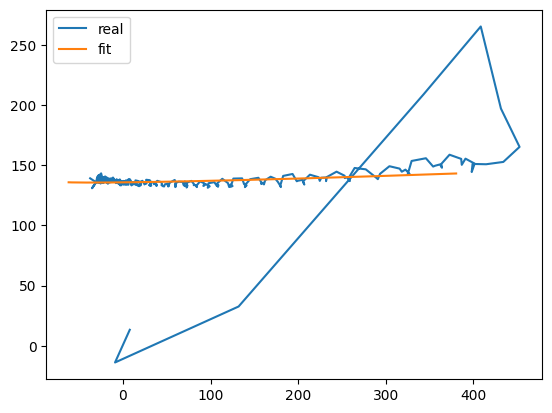

In [26]:
shots0 = X_all_0[:,0::2]+1j*X_all_0[:,1::2]
noise0 = shots0-z0_real

print(np.mean(np.abs(noise0)))
print(np.std(noise0.real))
print(np.std(noise0.imag))

plt.plot(z0_real.real,z0_real.imag,label="real")
plt.plot(z0_fit.real,z0_fit.imag,label="fit")
plt.legend()

print(params0)
print(params1)

In [27]:
print(shots0.shape)
print(z0_real.shape) 
print(noise0.shape)

print(np.mean(np.abs(z0_real)))
print(np.mean(np.abs(noise0)))

(500000, 770)
(770,)
(500000, 770)
156.01771466346364
1049.653255710921


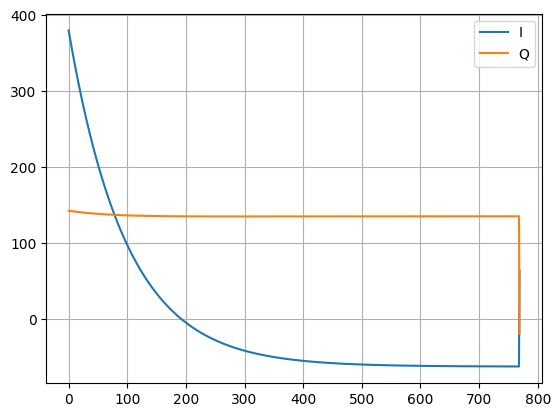

In [28]:
# Plot first shot
shot = X_2[1]
I = shot[0::2]
Q = shot[1::2]

plt.plot(I, label="I")
plt.plot(Q, label="Q")
plt.legend()
plt.grid()
plt.show()

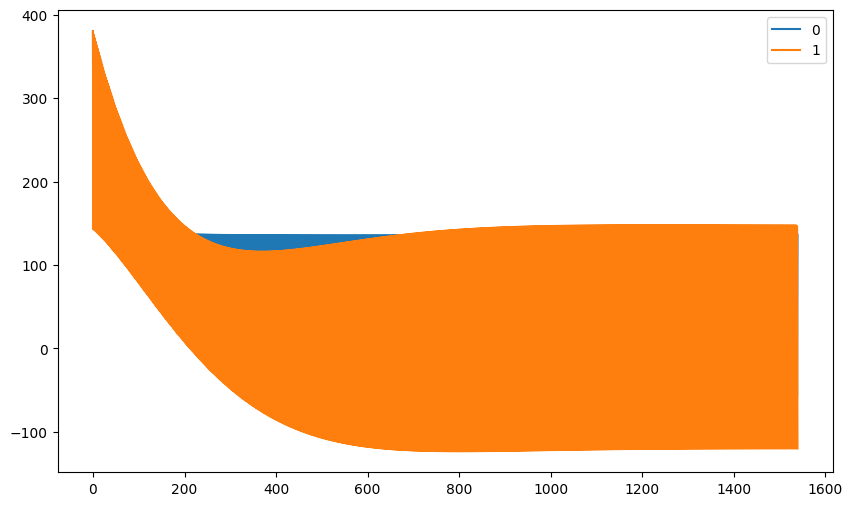

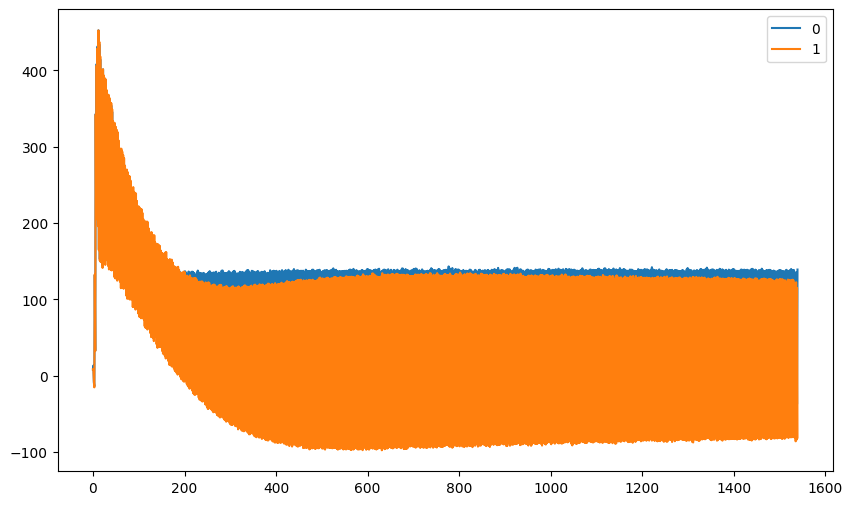

In [29]:
X0 = X_2[y_2==0]
X1 = X_2[y_2==1]

mean0 = np.mean(X0,axis=0)
mean1 = np.mean(X1,axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean0)
plt.plot(mean1)
plt.legend(["0","1"])

mean_real0 = np.mean(X_all_0, axis=0)
mean_real1 = np.mean(X_all_1, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_real0)
plt.plot(mean_real1)
plt.legend(["0","1"])

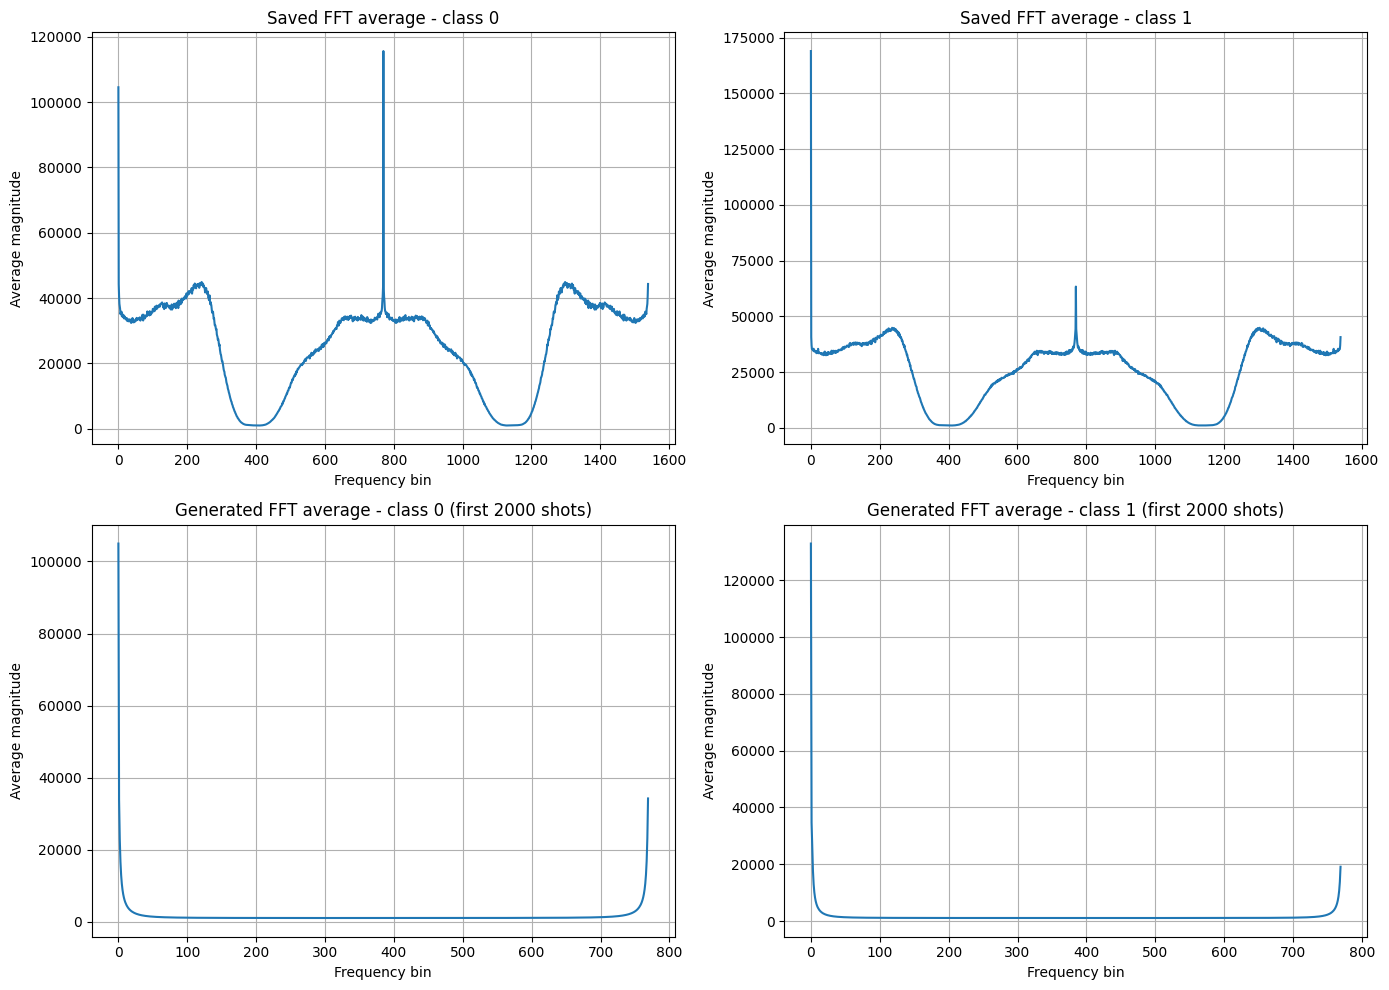

In [30]:
# Plot average FFT magnitude for saved FFT class 0/1 and generated FFT class 0/1

# Saved FFT averages by class
saved_fft_0_avg = np.mean(np.abs(X_all_0_fft_loaded[:2000]), axis=0)
saved_fft_1_avg = np.mean(np.abs(X_all_1_fft_loaded[:2000]), axis=0)

# Generated FFT averages by class
num_gen = min(2000, X_2.shape[0])
X_2_first = X_2[:num_gen]
X_2_complex = X_2_first[:, 0::2] + 1j * X_2_first[:, 1::2]
X_2_fft = np.fft.fft(X_2_complex, axis=1)

X_2_avg_0 = np.mean(np.abs(X_2_fft[y_2[:num_gen] == 0]), axis=0)
X_2_avg_1 = np.mean(np.abs(X_2_fft[y_2[:num_gen] == 1]), axis=0)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(saved_fft_0_avg)
plt.title('Saved FFT average - class 0')
plt.xlabel('Frequency bin')
plt.ylabel('Average magnitude')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(saved_fft_1_avg)
plt.title('Saved FFT average - class 1')
plt.xlabel('Frequency bin')
plt.ylabel('Average magnitude')
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(X_2_avg_0)
plt.title(f'Generated FFT average - class 0 (first {num_gen} shots)')
plt.xlabel('Frequency bin')
plt.ylabel('Average magnitude')
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(X_2_avg_1)
plt.title(f'Generated FFT average - class 1 (first {num_gen} shots)')
plt.xlabel('Frequency bin')
plt.ylabel('Average magnitude')
plt.grid()

plt.tight_layout()
plt.show()